In [1]:
import numpy as np
import glob
import os

import matplotlib.pyplot as plt

from scripts_fermions.operators import Hamiltonian, Boost
import yastn
from yastn.tn import mps

In [2]:
Nas = [(256, 0.125), (512, 0.125)]
dEs = [-644.4618759299467 + 645.0617359295529, 1291.555420267803 - 1290.961527431732]
v, Q = 1, 1
g = 1
m = 0

In [3]:
probs = {(N, a): np.load(f"./results_fermions/probs_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}
probs_gs = {(N, a): np.load(f"./results_fermions/probs_gs_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}

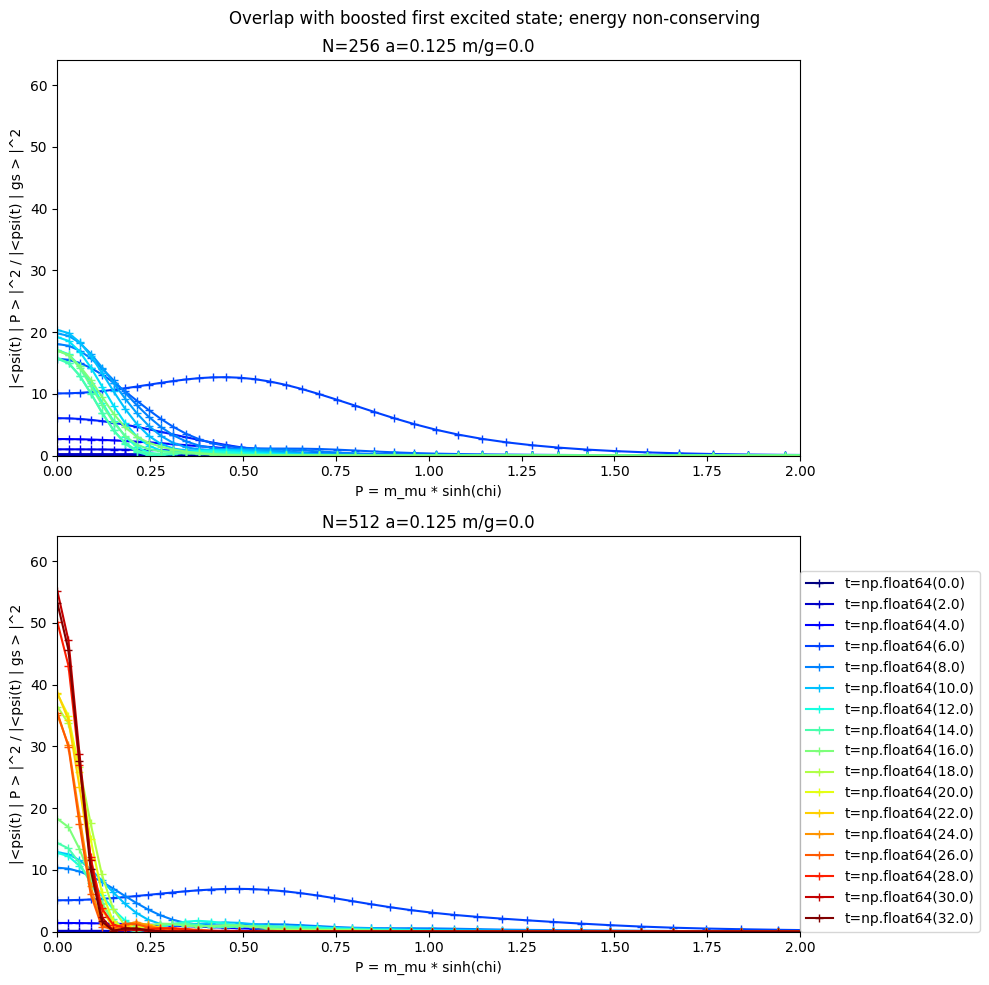

In [5]:
cm = plt.cm.jet
fig, axs = plt.subplots(len(Nas), 1, squeeze=False)
fig.set_size_inches(10, len(Nas) * 5)
for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  # t, D, chi
    chis = sorted(set(chi for t, D, chi in probs[N, a]))
    ts = sorted(set(t for t, D, chi in probs[N, a]))
    Ds = sorted(set(D for t, D, chi in probs[N, a]))
    Ds = [256]
    #
    jj = 0
    for D in Ds:
        for t in ts:
            pr = [probs[N, a][t, D, chi] / probs_gs[N, a][t, D] for chi in chis]
            P = np.sinh(chis) * (dE)
            sym = '-+' if D == Ds[0] else '-o'
            line, = axs[ii, jj].plot(P, pr, sym, color = cm(t / 32))
            if D == Ds[0]:
              line.set_label(f"{t=}")
    axs[ii,jj].set_xlabel('P = m_mu * sinh(chi)')
    axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
    axs[ii,jj].set_xlim([0, 2])
    axs[ii,jj].set_title(f"{N=} {a=} {m/g=}")
    axs[ii,jj].set_ylim([0, 64])

axs[-1, -1].legend(loc=(1, 0))
fig.suptitle("Overlap with boosted first excited state; energy non-conserving")

plt.tight_layout()


In [6]:
PPs = np.linspace(0, 3, 25)
probs_R = {(N, a): np.load(f"./results_fermions/probs_R_{m=}_{N=}_{a=}.npy", allow_pickle=True).item() for N, a in Nas}


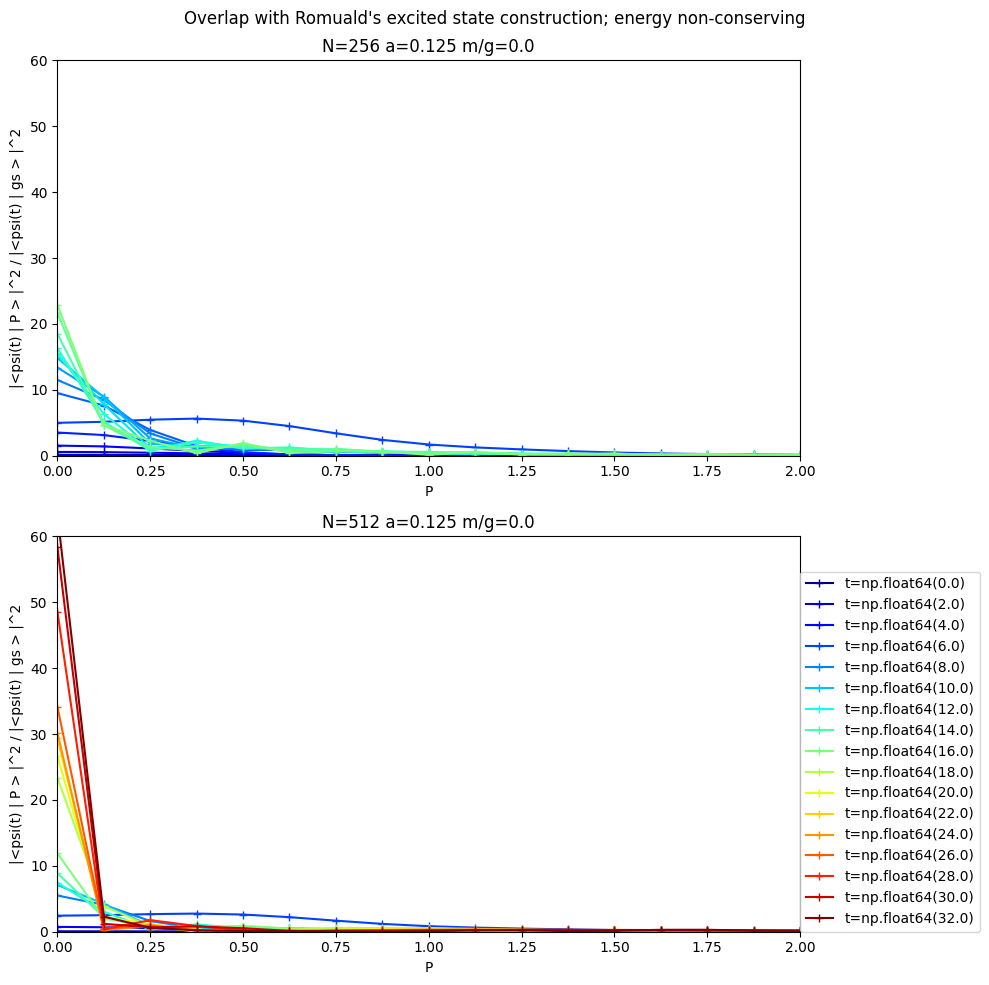

In [7]:
cm = plt.cm.jet
Ps = [0, 1, 2, 4]

PPs = np.linspace(0, 3, 25)


fig, axs = plt.subplots(len(Nas), 1, squeeze=False)
fig.set_size_inches(10, len(Nas) * 5)

for ii, ((N, a), dE) in enumerate(zip(Nas, dEs)):
  #
  ts = sorted(set(t for t, D, chi in probs_R[N, a]))
  Ds = sorted(set(D for t, D, chi in probs_R[N, a]))
  Ds = [256]
  #
  jj = 0
  for D in Ds:
    for t in ts:
      pr = [probs_R[N, a][t, D, P] / probs_gs[N, a][t, D] for P in PPs]
      sym = '-+' if D == Ds[0] else '-o'
      line, = axs[ii, jj].plot(PPs, pr, sym, color = cm(t / 32))
      if D == Ds[0]:
        line.set_label(f"{t=}")
  axs[ii,jj].set_xlabel('P')
  axs[ii,jj].set_ylabel("|<psi(t) | P > |^2 / |<psi(t) | gs > |^2")
  axs[ii,jj].set_xlim([0, 2])
  axs[ii,jj].set_title(f"{N=} {a=} {m/g=}")
  axs[ii,jj].set_ylim([0, 60])

axs[-1, -1].legend(loc=(1, 0))
fig.suptitle("Overlap with Romuald's excited state construction; energy non-conserving")
plt.tight_layout()
